<a href="https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Building and Visualizing Emissions Data with Google Data Commons

**Part 2 of 3: Constructing Time Series Datasets and Comparing States**

---

Welcome to the second notebook in the **Google Data Commons for Knowledge Discovery** tutorial series!

In this notebook, we’ll move beyond individual API calls and build a **multi-dimensional dataset** of greenhouse gas emissions across all U.S. states. We'll retrieve **time series data**, combine it with **location metadata**, and visualize patterns using both **static** and **interactive** visualizations.

### 🧭 Previously in Part 1:

We introduced the structure of the [**Knowledge Graph**](https://datacommons.org/browser/), explored how to identify entities using DCIDs, and queried relationship triples using get_triples(). We also visualized entity-level connections using NetworkX, laying the groundwork for deeper exploration.

---

## 🔍 What You'll Learn in This Notebook

- How to build a state-level emissions dataset using `get_stat_series()`
- How to retrieve population and geographic metadata
- How to compute per capita emissions
- How to visualize environmental patterns over time
  - Line plots with Seaborn
  - Interactive dashboards with Plotly

---

📚 **Tutorial Series Overview**:

1. ✅ **[Basics of Data Commons and Knowledge Graphs](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb)**  
2. 📈 **[Building and Visualizing Emissions Datasets](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)** (this notebook)  
3. 🌐 **[Interconnectivity and Event Exploration in GDC](#)**

> This notebook assumes you've seen the core API functions, but will reintroduce key methods where needed.


# Setup Cell — Installation + Imports

Here are the setups you will need to run this notebook

In [54]:
# ⚙️ Setup: Install packages if needed (for Google Colab only)
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install datacommons datacommons_pandas pygraphviz

# 📦 Imports
import datacommons as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# Set inline visuals
%config InlineBackend.figure_format = 'retina'


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


# Short API Recap & Core Concepts Markdown

## 🧠 Quick Recap: What is Data Commons?

This is the recap from the [first notebook](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb) - refer to it for a more detailed breakdown of Data Commons structure and API usage.

Google **Data Commons** integrates open data from sources like the U.S. Census, EPA, and World Bank into a unified **Knowledge Graph**.

In this graph:
- **Entities** (like states, cities, or events) are identified using **DCIDs**
- **Relationships** and **Statistical Variables** connect those entities through time and space

If you're new to these concepts, we recommend reviewing [Notebook 1](#) for:
- Knowledge Graph structure
- Understanding DCIDs and `get_triples()`
- Graph visualization basics

---

## 🛠️ Key API Methods Used in This Notebook

| **Method**                      | **What it does**                                 |
|--------------------------------|--------------------------------------------------|
| `get_places_in()`              | Get all U.S. states (`place_type = "State"`)     |
| `get_stat_series()`            | Retrieve time-series data for a variable         |
| `get_property_values()`        | Fetch metadata (e.g., name, location, nearby)    |

These tools allow us to construct **time-indexed datasets** and enrich them with geographic context.


# Section 1: Retrieving the data with Data Commons

## 🗺️ Step 1: Get All U.S. States and Define Variables

We’ll begin by retrieving all U.S. states from the Data Commons graph using `get_places_in()`.

Then, we’ll define the **statistical variables** that we want to pull for each state, including:
- Greenhouse gas emissions (biogenic & non-biogenic CO₂, methane, nitrous oxide)
- Total population (for per capita normalization)


## ✅ Code Cell: Retrieve States and Define Variables



In [55]:
# Get all US states using place_type = "State"
states_dict = dc.get_places_in(['country/USA'], place_type='State')
states_list = states_dict['country/USA']

# Define the statistical variables we want for each state
variables_list = [
    'Count_Person',
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic'
]

print(f"✅ Retrieved {len(states_list)} states.")


✅ Retrieved 52 states.


### 🔍 What Did We Just Do?

We used the function `get_places_in()` to retrieve the DCIDs for all **U.S. states** from the Data Commons knowledge graph.

Then, we defined a list of **statistical variables** we’ll collect for each state:
- Total population
- CO₂ emissions (biogenic and non-biogenic)
- Methane and nitrous oxide emissions

> ✅ The output confirms that we successfully retrieved **52 state-level entities** (including D.C. and territories, depending on API availability).


## ⏳ Step 2: Retrieve Emissions and Population Time Series

We’ll now loop over each state and each variable to retrieve **annual time series data** using `get_stat_series()`.

Each call returns a dictionary where:
- Keys = years (`'2010'`, `'2021'`, etc.)
- Values = observed metric (e.g., metric tons of CO₂)

We’ll flatten the results into a list of dictionaries to build a tidy Pandas DataFrame.


## ✅ Code Cell: Fetch Time Series Data

In [56]:
# Initialize a list to collect all data points
data = []

# Loop over each state and variable to retrieve time series data
for state in states_list:
    for var in variables_list:
        try:
            stat_series = dc.get_stat_series(state, var)
            for year, value in stat_series.items():
                data.append({
                    'State': state,
                    'Year': year,
                    'Variable': var,
                    'Value': value
                })
        except Exception as e:
            print(f"⚠️ Error fetching {var} for {state}: {e}")


In [57]:
data[:5]

[{'State': 'geoId/01',
  'Year': '1929',
  'Variable': 'Count_Person',
  'Value': 2644000},
 {'State': 'geoId/01',
  'Year': '1916',
  'Variable': 'Count_Person',
  'Value': 2359000},
 {'State': 'geoId/01',
  'Year': '1951',
  'Variable': 'Count_Person',
  'Value': 3059000},
 {'State': 'geoId/01',
  'Year': '2015',
  'Variable': 'Count_Person',
  'Value': 4854803},
 {'State': 'geoId/01',
  'Year': '1947',
  'Variable': 'Count_Person',
  'Value': 2942000}]

### 🗂️ What This Gave Us

We now have a **Python list of dictionaries**, where each dictionary is a data point representing:

- A state (by its DCID, like `'geoId/06'`)
- A year (as a string, like `'2015'`)
- A variable (e.g., `'Count_Person'`)
- A numeric value (e.g., population or emissions)

Here’s an example of what the structure looks like:

```python
[{
    'State': 'geoId/01',
    'Year': '2013',
    'Variable': 'Count_Person',
    'Value': 4831586
}, {
    'State': 'geoId/01',
    'Year': '2010',
    'Variable': 'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Value': 97000000.0
}]


This is still **raw structured data**.

> ✅ In the next step, we’ll convert this into a proper Pandas DataFrame and pivot it into wide format for analysis.

## 🧼 Step 3: Create a Tidy Dataset (Wide Format)

Now that we’ve collected a structured list of time series data, let’s convert it into a **Pandas DataFrame**.

Then we’ll **pivot** it so that:
- Each row represents a unique `(State, Year)`
- Each column corresponds to a different variable (e.g., population, emissions)

This makes it easier to compute metrics like **per capita emissions** and to visualize trends over time.


## ✅ Code Cell: Pivot to Wide Format

In [58]:
# Convert to DataFrame
df_long = pd.DataFrame(data)

# Convert Year to int for easier sorting
df_long['Year'] = df_long['Year'].astype(int)

# Pivot: one row per (State, Year), one column per Variable
df_wide = df_long.pivot_table(
    index=['State', 'Year'],
    columns='Variable',
    values='Value'
).reset_index()

# Optional: sort values for clarity
df_wide = df_wide.sort_values(by=['State', 'Year']).reset_index(drop=True)

df_wide.head()


Variable,State,Year,Annual_Emissions_CarbonDioxide_Biogenic,Annual_Emissions_CarbonDioxide_NonBiogenic,Annual_Emissions_Methane_NonBiogenic,Annual_Emissions_NitrousOxide_NonBiogenic,Count_Person
0,geoId/01,1900,NaN,NaN,NaN,NaN,1830000.0
1,geoId/01,1901,NaN,NaN,NaN,NaN,1907000.0
2,geoId/01,1902,NaN,NaN,NaN,NaN,1935000.0
3,geoId/01,1903,NaN,NaN,NaN,NaN,1957000.0
4,geoId/01,1904,NaN,NaN,NaN,NaN,1978000.0


### 📊 What This Table Shows

You now have a wide-format dataset with one row per **State-Year** combination, and each column representing a **measured variable**.

For example:

| State     | Year | Count_Person | Annual_Emissions_CO₂_NonBiogenic | ... |
|-----------|------|---------------|-------------------------------|------|
| geoId/01  | 2010 | 4,800,000     | 97,000,000                   | ...  |
| geoId/01  | 2011 | 4,820,000     | 96,000,000                   | ...  |

> ✅ In the next step, we’ll compute **per capita emissions** by dividing the emissions values by population.


## 📐 Step 4: Compute Per Capita Emissions

To make meaningful comparisons across states, we’ll normalize emissions data by population size. This gives us **per capita** metrics:

- CO₂ per person (biogenic and non-biogenic)
- Methane per person
- Nitrous oxide per person

We'll add new columns to the DataFrame with `_per_capita` suffixes.


## ✅ Code Cell: Calculate Per Capita Columns

In [59]:
# Create new per capita columns
df_wide['CO2_Bio_per_capita'] = (
    df_wide['Annual_Emissions_CarbonDioxide_Biogenic'] / df_wide['Count_Person']
)

df_wide['CO2_NonBio_per_capita'] = (
    df_wide['Annual_Emissions_CarbonDioxide_NonBiogenic'] / df_wide['Count_Person']
)

df_wide['Methane_per_capita'] = (
    df_wide['Annual_Emissions_Methane_NonBiogenic'] / df_wide['Count_Person']
)

df_wide['N2O_per_capita'] = (
    df_wide['Annual_Emissions_NitrousOxide_NonBiogenic'] / df_wide['Count_Person']
)

# Preview the result
df_wide[['State', 'Year', 'CO2_NonBio_per_capita', 'Methane_per_capita']].head()


Variable,State,Year,CO2_NonBio_per_capita,Methane_per_capita
0,geoId/01,1900,NaN,NaN
1,geoId/01,1901,NaN,NaN
2,geoId/01,1902,NaN,NaN
3,geoId/01,1903,NaN,NaN
4,geoId/01,1904,NaN,NaN


### 📈 What These Columns Represent

Each of these new columns shows **emissions per person**, allowing us to:

- Compare states fairly despite different population sizes
- Track how emissions intensity has changed over time

> ✅ Up next: we’ll enrich this dataset with geographic metadata like state names and coordinates to enable mapping and region-based filtering.


## 🗺️ Step 5: Enrich with Metadata (Name, Location)

We’ve built a solid emissions dataset by state and year — but our current `State` column still uses **DCIDs** (like `'geoId/06'`).

Let’s add additional metadata for each state to make the dataset more readable and flexible for:
- Visualization and labeling
- metadata enrichement


## ✅ Code Cell: Fetch Metadata from Data Commons

In [60]:
# --- Step 5.1: Collect names, lat, lon ---
unique_states = df_wide['State'].unique()
state_names = {}
state_coords = {}

for dcid in unique_states:
    try:
        name = dc.get_property_values([dcid], 'name').get(dcid, [''])[0]
        lat = dc.get_property_values([dcid], 'latitude').get(dcid, [''])[0]
        lon = dc.get_property_values([dcid], 'longitude').get(dcid, [''])[0]

        state_names[dcid] = name
        state_coords[dcid] = (lat, lon)
    except Exception as e:
        print(f"⚠️ Name/coords failed for {dcid}: {e}")






In [61]:
# Show a sample of the metadata collected

print("🔤 State Names (first 5):")
for k in list(state_names.keys())[:5]:
    print(f"{k} → {state_names[k]}")

print("\n📍 State Coordinates (first 5):")
for k in list(state_coords.keys())[:5]:
    lat, lon = state_coords[k]
    print(f"{state_names[k]} → lat: {lat}, lon: {lon}")



🔤 State Names (first 5):
geoId/01 → Alabama
geoId/02 → Alaska
geoId/04 → Arizona
geoId/05 → Arkansas
geoId/06 → California

📍 State Coordinates (first 5):
Alabama → lat: 32.7, lon: -86.7
Alaska → lat: 63.346191, lon: -150
Arizona → lat: 34.2099643, lon: -111.602401
Arkansas → lat: 34.8, lon: -92.2
California → lat: 37, lon: -119.5406515


### ✅ What to Check

You should see:
- ✅ Full state names matched to DCIDs
- ✅ Approximate lat/lon values


This confirms that the **metadata enrichment** step worked before we merge everything into the main emissions dataset.


### What Did We Just Fetch?

### 🧭 Interpreting the Metadata

For each state DCID, we’ve now collected:

| Field            | Description                                     |
|------------------|-------------------------------------------------|
| `name`           | Full state name (e.g., "California")            |
| `latitude`, `longitude` | Approximate geographic center of the state   |


> ✅ In the next step, we’ll merge this metadata into our main dataset so we can use it for labels, filters, and maps.


## 🧩 Step 6: Merge Metadata into the Emissions Dataset

We’ll now map the metadata we retrieved into new columns:

- `Name` → readable state name
- `Lat`, `Lon` → geographic coordinates


This allows us to:
- Use friendly labels in plots

- Later build interactive dashboards


## ✅ Code Cell: Merge Metadata into df_wide

In [62]:
# 🧩 Step 6: Map Metadata into Main Dataset

# Add readable state names
df_wide['Name'] = df_wide['State'].map(state_names)

# Split coordinates into two separate mappings
latitudes = {k: v[0] for k, v in state_coords.items()}
longitudes = {k: v[1] for k, v in state_coords.items()}

# Add latitude and longitude as separate columns
df_wide['Lat'] = df_wide['State'].map(latitudes)
df_wide['Lon'] = df_wide['State'].map(longitudes)



# Preview merged columns
df_wide[['State', 'Name', 'Year', 'CO2_NonBio_per_capita', 'Lat', 'Lon']].head()


Variable,State,Name,Year,CO2_NonBio_per_capita,Lat,Lon
0,geoId/01,Alabama,1900,NaN,32.7,-86.7
1,geoId/01,Alabama,1901,NaN,32.7,-86.7
2,geoId/01,Alabama,1902,NaN,32.7,-86.7
3,geoId/01,Alabama,1903,NaN,32.7,-86.7
4,geoId/01,Alabama,1904,NaN,32.7,-86.7


### ✅ What You Should See Now

Each row should include:

- A readable state name (e.g., "Alabama")
- Geographic coordinates (`Lat`, `Lon`)



## 🧹 Step 7: Final Clean-Up and Dataset Overview

We’ve now created a dataset that combines:

- Time series data on emissions and population
- Derived per capita metrics
- Geographic metadata (names, coordinates)

We removed the `Nearby_Places` field since it’s not supported at the state level in Data Commons.

Let’s preview the final dataset before visualizing it.


## ✅ Code Cell:  Preview the final enriched dataset

In [63]:
# Preview the final dataset
df_wide.head()


Variable,State,Year,Annual_Emissions_CarbonDioxide_Biogenic,Annual_Emissions_CarbonDioxide_NonBiogenic,Annual_Emissions_Methane_NonBiogenic,Annual_Emissions_NitrousOxide_NonBiogenic,Count_Person,CO2_Bio_per_capita,CO2_NonBio_per_capita,Methane_per_capita,N2O_per_capita,Name,Lat,Lon
0,geoId/01,1900,NaN,NaN,NaN,NaN,1830000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
1,geoId/01,1901,NaN,NaN,NaN,NaN,1907000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
2,geoId/01,1902,NaN,NaN,NaN,NaN,1935000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
3,geoId/01,1903,NaN,NaN,NaN,NaN,1957000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7
4,geoId/01,1904,NaN,NaN,NaN,NaN,1978000.0,NaN,NaN,NaN,NaN,Alabama,32.7,-86.7


In [64]:
df_wide.columns

Index(['State', 'Year', 'Annual_Emissions_CarbonDioxide_Biogenic',
       'Annual_Emissions_CarbonDioxide_NonBiogenic',
       'Annual_Emissions_Methane_NonBiogenic',
       'Annual_Emissions_NitrousOxide_NonBiogenic', 'Count_Person',
       'CO2_Bio_per_capita', 'CO2_NonBio_per_capita', 'Methane_per_capita',
       'N2O_per_capita', 'Name', 'Lat', 'Lon'],
      dtype='object', name='Variable')

## 🧾 Final Dataset Columns (So Far)

Here’s what each column in our `df_wide` dataset represents:

| Column                          | Description                                                                 |
|---------------------------------|-----------------------------------------------------------------------------|
| `State`                         | DCID (Data Commons ID) for the state, e.g., `geoId/06`                      |
| `Name`                          | Human-readable state name (e.g., `"California"`)                            |
| `Year`                          | Year of the observation                                                     |
| `Count_Person`                  | Total population in that state and year                                     |
| `Annual_Emissions_CarbonDioxide_Biogenic` | Annual CO₂ emissions from **biogenic** sources (e.g., forests, ag)       |
| `Annual_Emissions_CarbonDioxide_NonBiogenic` | Annual CO₂ emissions from **non-biogenic** sources (e.g., fossil fuels) |
| `Annual_Emissions_Methane_NonBiogenic` | Annual methane emissions from human-caused sources                       |
| `Annual_Emissions_NitrousOxide_NonBiogenic` | Annual nitrous oxide emissions from industrial/ag activities            |
| `CO2_Bio_per_capita`            | Biogenic CO₂ per person (emissions ÷ population)                            |
| `CO2_NonBio_per_capita`         | Non-biogenic CO₂ per person                                                 |
| `Methane_per_capita`            | Methane per person                                                          |
| `N2O_per_capita`                | Nitrous oxide per person                                                    |
| `Lat`, `Lon`                    | Approximate coordinates of the state center                                 |


> ✅ This dataset is now fully ready for exploration and visualization.


# Section 2: Visualizing and exploring the retrieved dataset

---

## 📈 Step 8.1: Visualize Emissions Trends (Seaborn)

We’ll now visualize emissions over time using **Seaborn line plots**, focusing on:

- **One state at a time**, or
- **Comparing multiple states**

This helps us:
- See how emissions evolved over the past decade
- Spot outliers and high-emission regions
- Evaluate trends in per capita impact

Let’s start with a basic line plot for **CO₂ per capita emissions**.


We'll start by plotting:
- **Non-biogenic CO₂ per capita** (i.e., fossil fuel emissions)
- For a selected set of states
- Using Seaborn’s `lineplot()`

This helps us identify high-emission states and temporal shifts.

## ✅ Code Cell: Basic Seaborn Line Plot (Static)

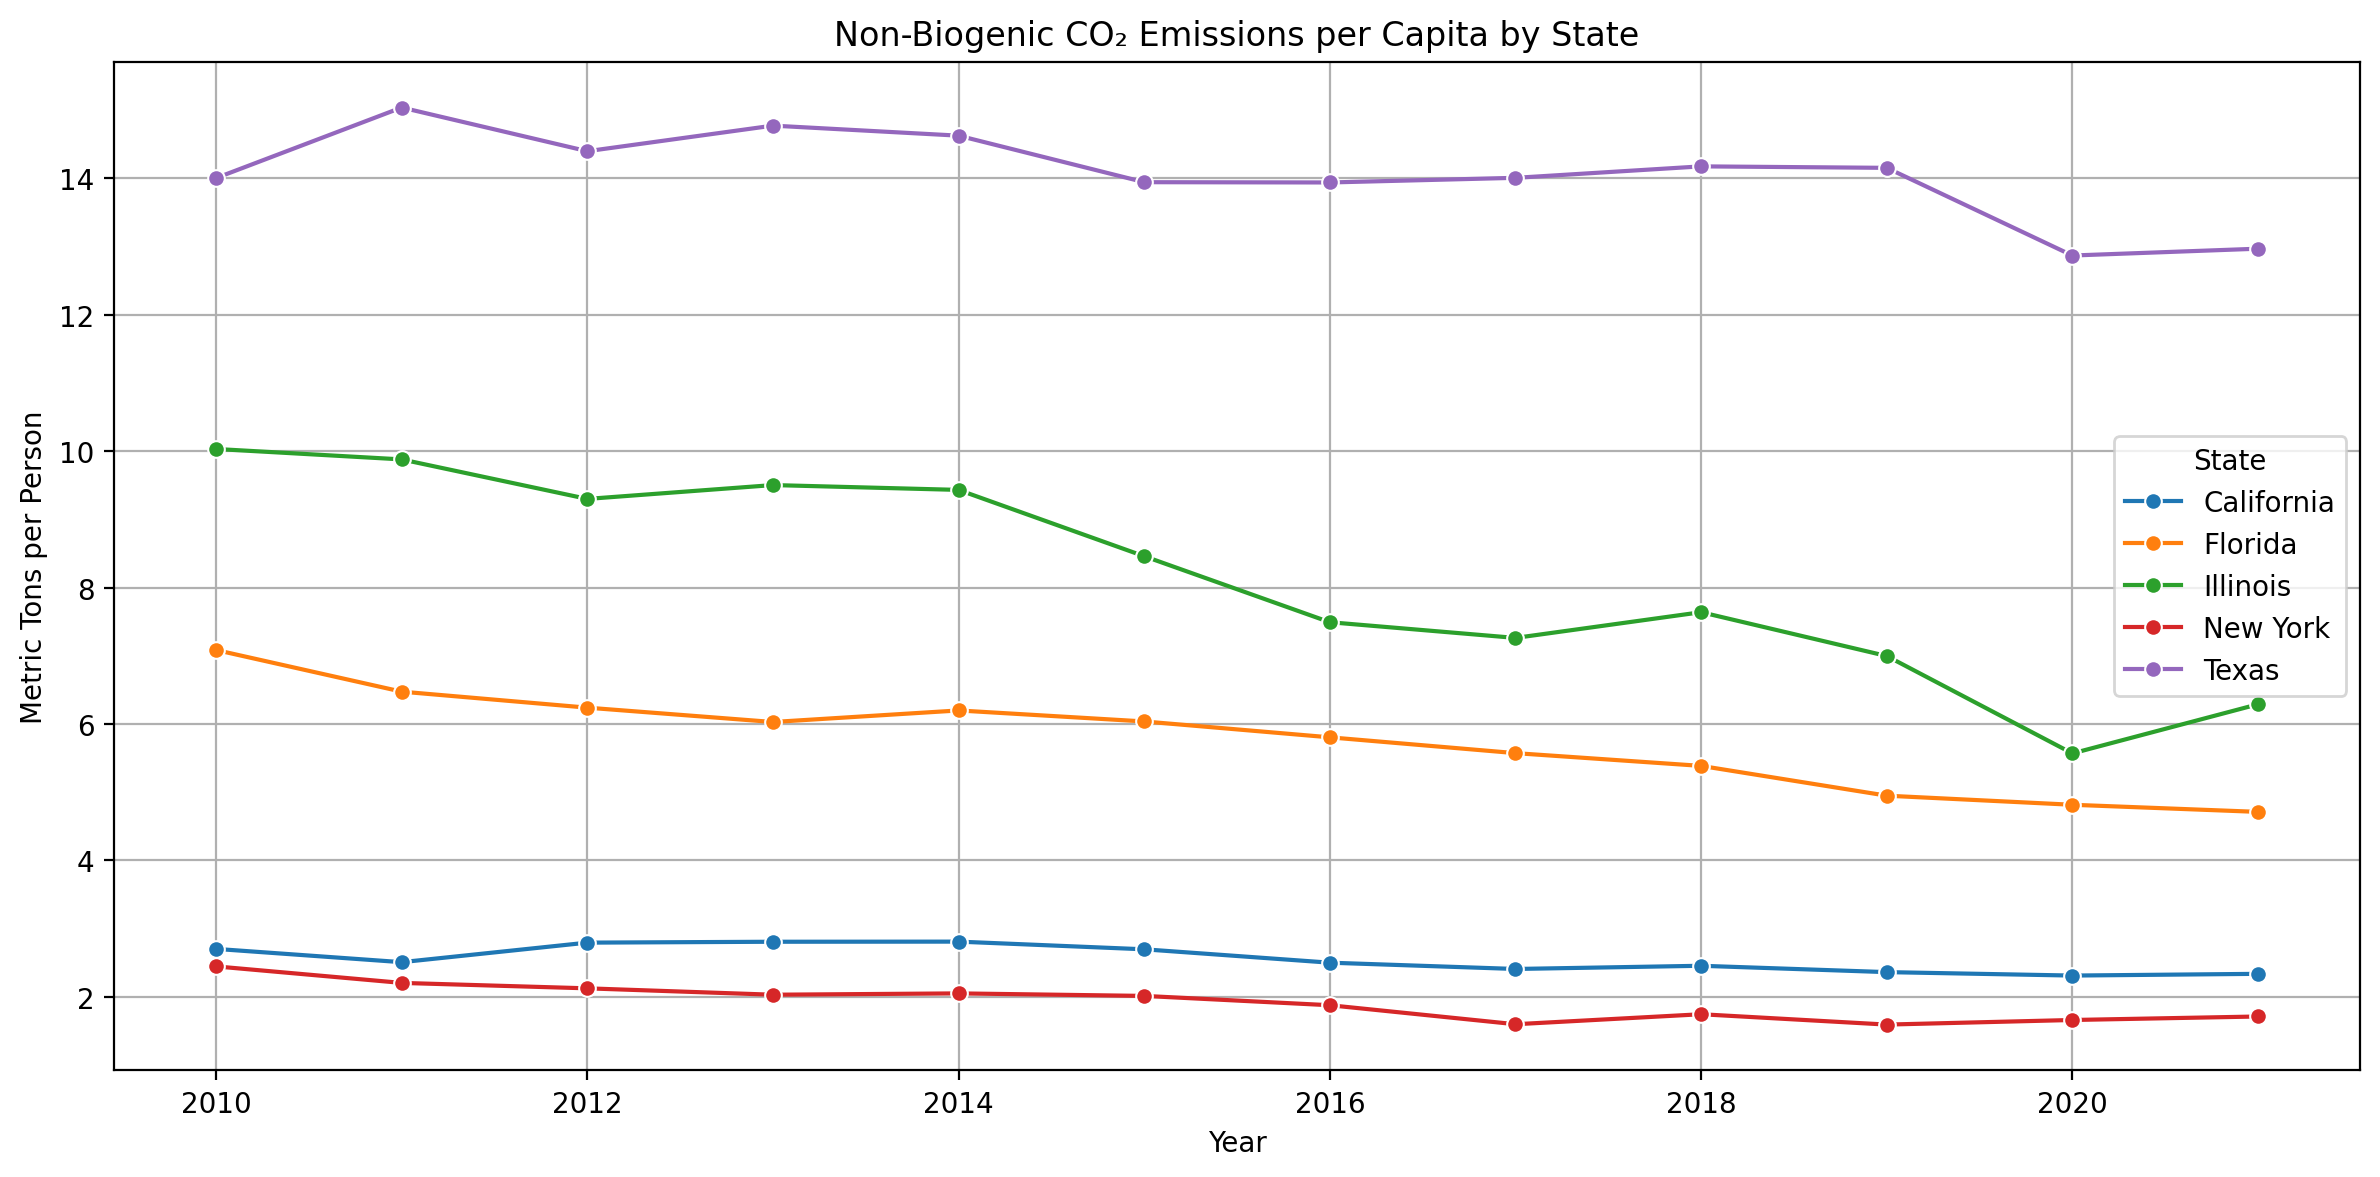

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a few states to compare
selected_states = ['California', 'Texas', 'Florida', 'New York', 'Illinois']

# Filter the dataframe
plot_df = df_wide[df_wide['Name'].isin(selected_states)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Year', y='CO2_NonBio_per_capita', hue='Name', marker='o')

plt.title("Non-Biogenic CO₂ Emissions per Capita by State")
plt.ylabel("Metric Tons per Person")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.legend(title="State")
plt.show()


### 📊 Interpretation: Non-Biogenic CO₂ per Capita Trends

This line chart shows the **non-biogenic CO₂ emissions per person** across five major U.S. states from 2010 to 2021.

- **Texas** has consistently the **highest per capita emissions**, likely due to energy production and industry.
- **New York** and **California** show the **lowest levels**, reflecting strong environmental regulations and energy efficiency efforts.
- **Illinois** and **Florida** are in the middle, but show a general **downward trend** over time.

> ✅ This kind of visualization helps policymakers and researchers evaluate the effectiveness of emission reduction strategies.


### 🔍 What to Look For

- Which states have the **highest per-person emissions**?
- Are emissions **increasing or decreasing** over time?
- Are any states moving in **opposite directions**?

> 🧠 You can easily change the `selected_states` list to explore different regions or create regional comparisons (e.g., West Coast vs Midwest).


## 📊 Step 8.2: Compare Different Gases per Capita (Single State View)

We’ve looked at how one metric changes over time across states.

Now let’s flip the question:
> **How do multiple emission types compare within a single state?**

We’ll plot several **per capita metrics** for one state (e.g., California), using Seaborn.


## ✅ Code Cell: Line Plot of Multiple Metrics (One State)

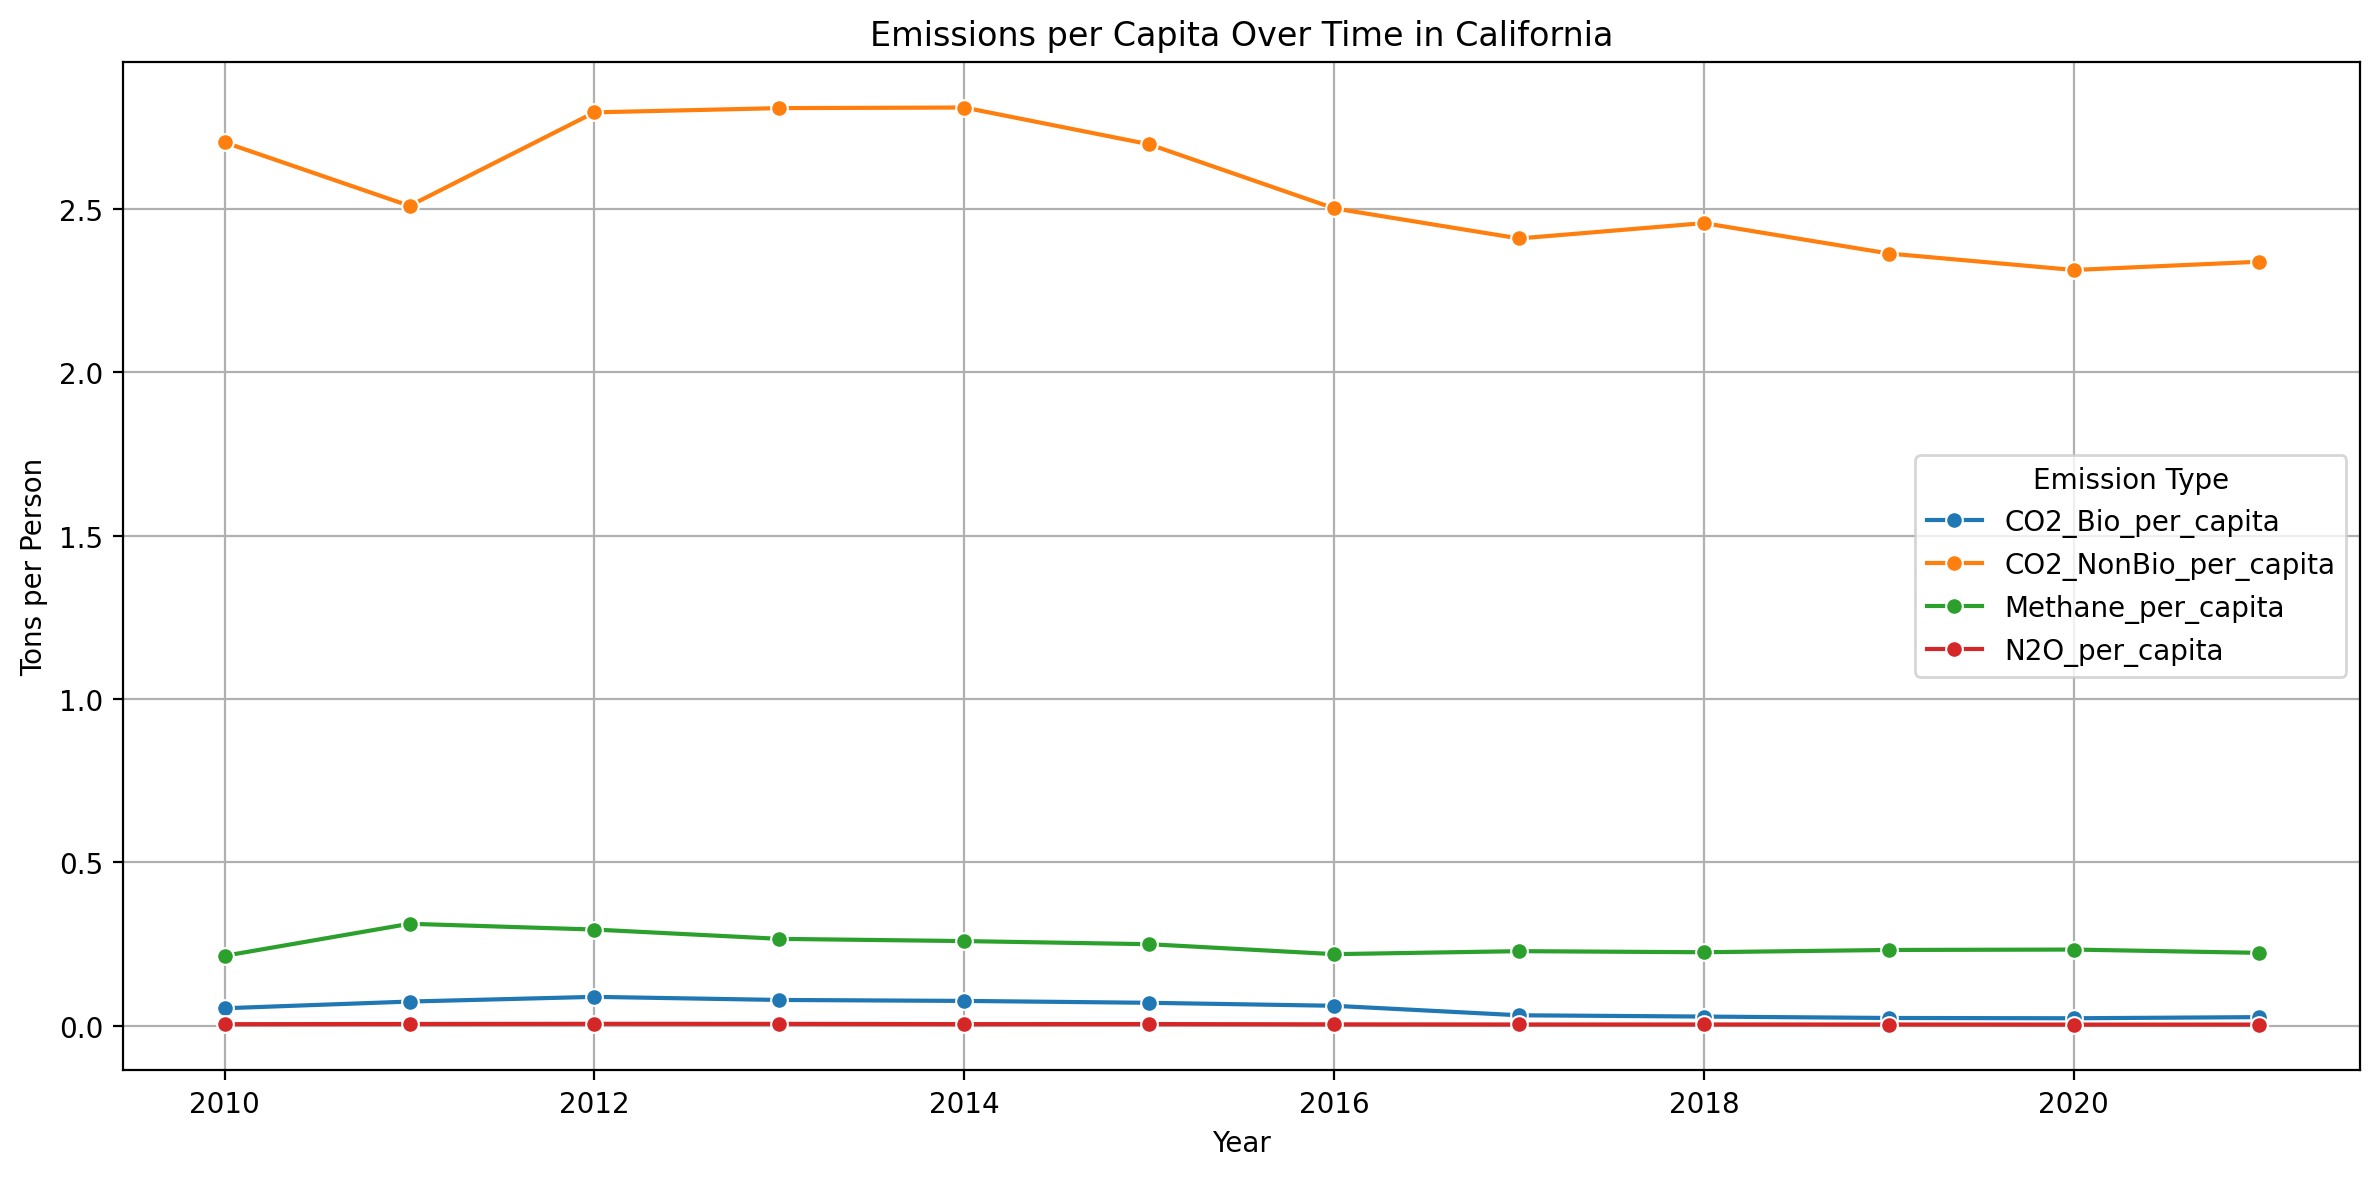

In [66]:
# Choose a state to explore
selected_state = 'California' ## you can change the state here

# Filter data
state_df = df_wide[df_wide['Name'] == selected_state]

# Melt the DataFrame to long format
melted = state_df.melt(
    id_vars=['Year'],
    value_vars=[
        'CO2_Bio_per_capita',
        'CO2_NonBio_per_capita',
        'Methane_per_capita',
        'N2O_per_capita'
    ],
    var_name='Metric',
    value_name='PerCapitaValue'
)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted, x='Year', y='PerCapitaValue', hue='Metric', marker='o')

plt.title(f"Emissions per Capita Over Time in {selected_state}")
plt.ylabel("Tons per Person")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Emission Type")
plt.show()


### 📊 Interpretation of Multi-Metric Plot

- **Non-Biogenic CO₂** is clearly the dominant emission per capita in California.
- **Methane (CH₄)** emissions are noticeably lower but still significant.
- **Biogenic CO₂** and **Nitrous Oxide (N₂O)** are minimal by comparison.
- The overall per-person emissions profile is **declining or stabilizing** over time, especially for CO₂.

This kind of comparison helps reveal **which types of emissions drive the state's overall footprint** — and how targeted policies might reduce specific gases.


### 🔍 What This Tells Us

- You can now **directly compare different gases** for a single state.
- You’ll often see **CO₂ (non-biogenic)** dominating.
- **Methane and N₂O** vary but tend to be lower.

This is useful for understanding the **emissions profile** of each state.

> 🔁 Want to explore a different state? Just change `selected_state`.


---

## 🧭 What’s Next: Interactive Plotly Dashboard

We’ve now visualized emissions by:
- 📈 Single metric across states (Step 8.1)
- 📊 Multiple metrics for one state (Step 8.2)

> 💡 **Why Interactivity Matters in Google Data Commons**
>
> Google Data Commons isn't just a data source — it's a **discovery platform** built on a **knowledge graph**.  
> With thousands of variables, locations, and relationships, **interactive exploration** becomes essential.  
> Static plots are great for predefined questions — but **dynamic dashboards help uncover new patterns**, compare across dimensions, and truly explore the knowledge graph.

So what if you want to:
- Compare multiple **states AND metrics** interactively?
- Select from dropdowns instead of hardcoding values?
- Quickly explore trends without writing new code?

🎛️ Let’s build an **interactive Plotly explorer** where you can:
- Select states and metrics on the fly
- Zoom into time periods
- Hover to see exact values

---


# Section 3: Interactive **Data Commons** Plots with Plotly

---

## 🎛️ Step 9: Interactive Emissions Explorer with Plotly

Now that we’ve seen how to plot emissions data using Seaborn, let's make the experience dynamic and interactive.

Using **Plotly**, we’ll build an explorer tool that allows you to:
- ✅ Select one or more states
- ✅ Choose emission variables to compare
- ✅ Zoom into specific years
- ✅ Hover to see precise values

> ⚠️ **Important Note:**
> Plotly interactive charts require running this notebook in **Google Colab**, **Jupyter**, or **JupyterLab**.
> If you are viewing this in GitHub or a static environment, the interactive plot **will not render**.
>
> To help with this, we’ll include **static preview images** of the charts below each Plotly cell.

---

### 🔄 How This Ties Back to Knowledge Discovery

Data Commons is designed to be **exploratory** — it contains thousands of interconnected indicators.  
Instead of hardcoding what to analyze, this dashboard lets **you drive your own investigation**.

Think of it as:
> 🧭 A knowledge discovery tool for surfacing insights hidden in the graph.

Let’s build it!

---


## 📦 Code: Step 9.1 – Interactive Plotly Chart (Single State + Variable)

## 📊 Step 9.1: Explore Emissions Trends by State & Variable

Use the interactive dropdowns below to select:
- A **state**
- An **emission variable** (e.g. CO₂, methane)

You'll get an interactive Plotly plot (⚠️ requires **Colab**, **Jupyter**, or a compatible environment).  
If viewing this notebook on GitHub or another static site, refer to the **static snapshot below** each plot for reference.


## ✅ Code Cell: Interactive Plot where you can choose state and metric displayed - helper functions

In [70]:
import plotly.graph_objects as go
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import os


class EmissionsExplorer:
    def __init__(self, df, metrics, default_state=None, default_metric=None):
        self.df = df
        self.states = df['Name'].unique()
        self.metrics = metrics
        self.default_state = default_state or self.states[0]
        self.default_metric = default_metric or self.metrics[0]
        self.min_year = 2000
        self.max_year = df['Year'].max()

    def create_interactive_plot(self):
        fig = go.Figure()

        # Add traces for all state-metric combinations
        for metric in self.metrics:
            for state in self.states:
                data = self.df[self.df['Name'] == state]
                fig.add_trace(go.Scatter(
                    x=data['Year'],
                    y=data[metric],
                    mode='lines+markers',
                    name=f'{state} - {metric}',
                    visible=False
                ))

        # Make only the default trace visible
        for i, trace in enumerate(fig.data):
            if trace.name == f'{self.default_state} - {self.default_metric}':
                fig.data[i].visible = True

        # Dropdown for states
        state_dropdown = {
            "buttons": [
                {
                    "label": state,
                    "method": "update",
                    "args": [
                        {"visible": [
                            trace.name == f"{state} - {self.default_metric}" for trace in fig.data
                        ]},
                        {"title": f"{state} - {self.default_metric}"}
                    ]
                } for state in self.states
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.01,
            "xanchor": "left",
            "y": 1.2,
            "yanchor": "top"
        }

        # Dropdown for metrics
        metric_dropdown = {
            "buttons": [
                {
                    "label": metric,
                    "method": "update",
                    "args": [
                        {"visible": [
                            trace.name == f"{self.default_state} - {metric}" for trace in fig.data
                        ]},
                        {"title": f"{self.default_state} - {metric}"}
                    ]
                } for metric in self.metrics
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.25,
            "xanchor": "left",
            "y": 1.2,
            "yanchor": "top"
        }

        # Layout
        fig.update_layout(
            title=f"{self.default_state} - {self.default_metric}",
            xaxis_title="Year",
            yaxis_title="Emissions",
            updatemenus=[state_dropdown, metric_dropdown],
            margin=dict(t=100),
            xaxis=dict(
                rangeslider=dict(visible=True),
                rangeselector=dict(
                    buttons=[
                        dict(count=5, label="Last 5Y", step="year", stepmode="backward"),
                        dict(count=10, label="Last 10Y", step="year", stepmode="backward"),
                        dict(step="all", label="All")
                    ]
                ),
                range=[self.min_year, self.max_year]
            )
        )

        return fig

    def generate_static_plots(self, state_metric_pairs):
        file_paths = []
        for i, (state, metric) in enumerate(state_metric_pairs):
            data = self.df[self.df['Name'] == state]
            fig = go.Figure()
            fig.add_trace(go.Scatter(
                x=data['Year'],
                y=data[metric],
                mode='lines+markers',
                name=f'{state} - {metric}'
            ))
            fig.update_layout(
                title=f"{state} - {metric}",
                xaxis_title="Year",
                yaxis_title="Emissions",
                xaxis=dict(range=[self.min_year, self.max_year])
            )

            path = os.path.join(static_output_dir, f"{state}_{metric}.png")
            pio.write_image(fig, path, format="png", scale=2)
            file_paths.append(path)

        return file_paths


# Display will be handled in the next step
"Class and static plot generation function is ready."



'Class and static plot generation function is ready.'

## 📦 Code Cell:  Interactive Plots
Now that we have defined functions to plot out interactive graph, let's plot it

In [99]:
import warnings
from IPython.display import display, Markdown

# Suppress warnings (especially Plotly deprecation warnings)
warnings.filterwarnings("ignore")

# Create explorer instance
explorer = EmissionsExplorer(df=df_wide, metrics=[
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic',
    'CO2_Bio_per_capita',
    'CO2_NonBio_per_capita',
    'Methane_per_capita',
    'N2O_per_capita'
])

# Create and show interactive Plotly figure
fig = explorer.create_interactive_plot()
fig.show()

# Fallback message
display(Markdown("""
> ✅ **Here is the interactive emissions explorer powered by Plotly.**
>
> If you **cannot see the plot above** (e.g., you're on GitHub or a static notebook viewer),
> please scroll down to the next code cells which **recreate the same plots using Matplotlib**
> for static export or offline use.
"""))



> ✅ **Here is the interactive emissions explorer powered by Plotly.**  
> 
> If you **cannot see the plot above** (e.g., you're on GitHub or a static notebook viewer),  
> please scroll down to the next code cells which **recreate the same plots using Matplotlib**  
> for static export or offline use.


## 📦 Code Cell:  Static Grid Generator Cell (Customize your view here)

If you couldn't or do not want to use Plotly you can create dynamic exploration with traditional Python visualization tools like matplotlib - they will be in static format rather then interactive html.

### 🖼️ Static Snapshots for GitHub or PDF Export

If Plotly isn't supported (e.g. GitHub renderers or PDF export), we use:

- `matplotlib` to recreate the same plots as PNGs
- Side-by-side comparisons by **fixing either a state or a metric**
- Example: Viewing emissions trends across **5 metrics** for **California**

> You can change the `fixed_state` or `fixed_metric` variables in the code to produce your own grid of static charts.

---



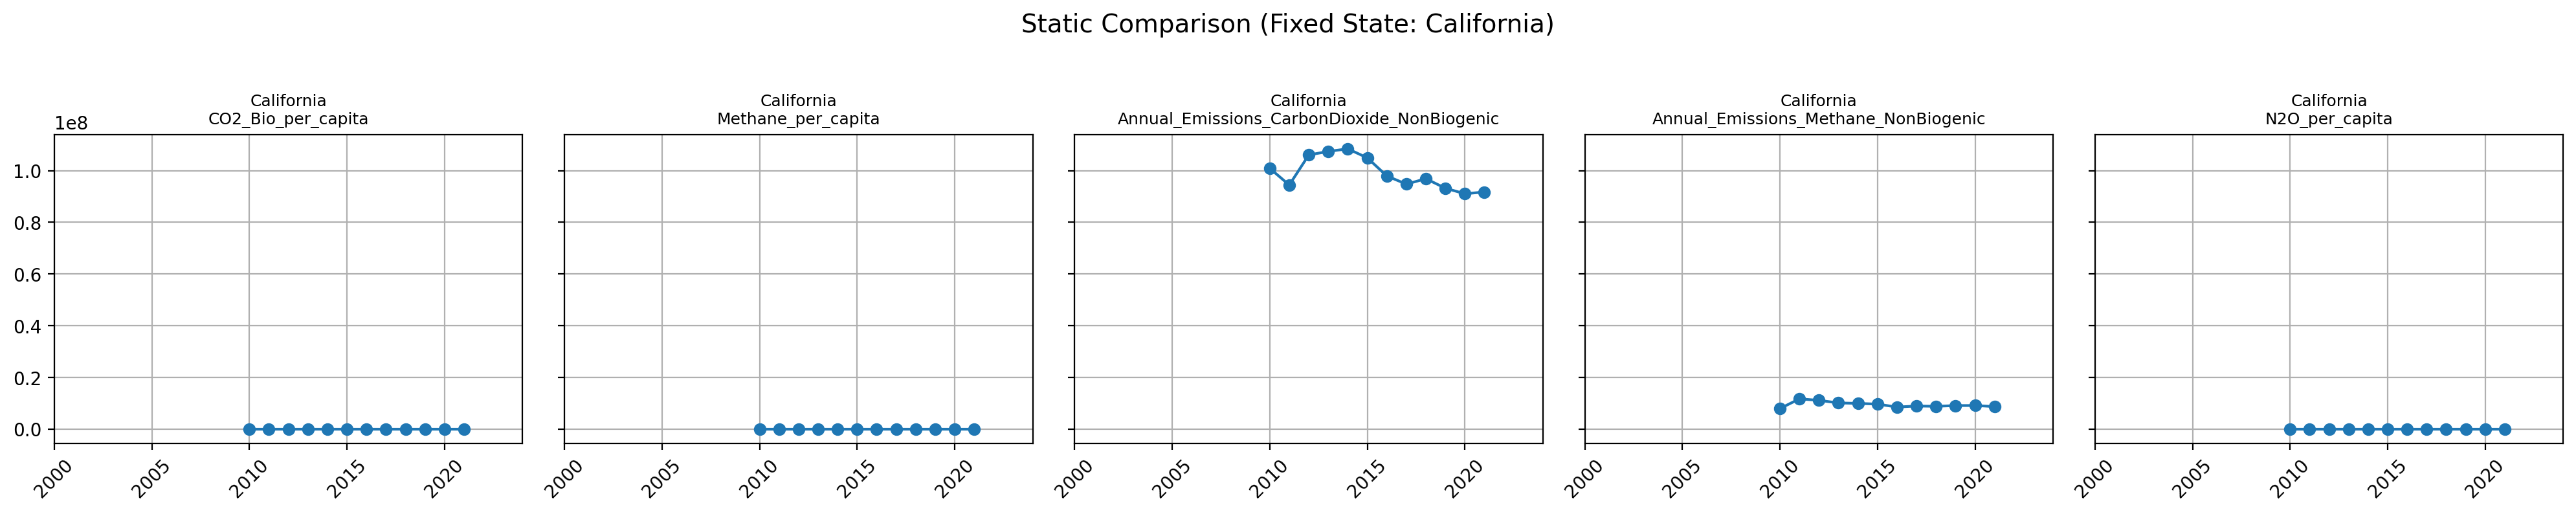

In [90]:
import matplotlib.pyplot as plt

# --------------------------
# ⚙️ SETTINGS (Customize here)
# --------------------------

# ✅ FIXED STATE across multiple metrics
fixed_state = "California"  # 👈 change to fix a different state
metrics_to_plot = [
    "CO2_Bio_per_capita",
    "Methane_per_capita",
    "Annual_Emissions_CarbonDioxide_NonBiogenic",
    "Annual_Emissions_Methane_NonBiogenic",
    "N2O_per_capita"
]

# ✅ OR, FIXED METRIC across multiple states
# fixed_metric = "Methane_per_capita"
# states_to_plot = ["California", "Texas", "New York", "Florida", "Illinois"]

# --------------------------
# 📊 STATIC PLOTS SIDE BY SIDE
# --------------------------

fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4), sharey=True)

for i, metric in enumerate(metrics_to_plot):
    data = df_wide[df_wide["Name"] == fixed_state]
    axs[i].plot(data["Year"], data[metric], marker='o', color='tab:blue')
    axs[i].set_title(f"{fixed_state}\n{metric}", fontsize=9)
    axs[i].set_xlim(2000, data["Year"].max())
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].grid(True)

fig.suptitle(f"Static Comparison (Fixed State: {fixed_state})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Part 2: Visualizing the emissions dataset.**

In this part of the tutorial, we show how to use the DataCommons API to construct a dataset of US states and their emissions data. We utilize the graph data structure of the DataCommons database to construct a dataset where each state will be linked to the other via the "nearby" places property of each state (node).

Imports:

In [16]:
#!pip install datacommons
import datacommons
import pandas as pd

* We will start by constructing a dataset for all US states that will be cross-referenced via nearby places property

In [17]:
# Getting US-states dcid (geo-id in case of states)
states = datacommons.get_places_in(['country/USA'],place_type='State')
states_list = states['country/USA']

In [18]:
## list of needed variables for each state
variables_list = [
    'Count_Person',
    'Annual_Emissions_CarbonDioxide_Biogenic',
    'Annual_Emissions_NitrousOxide_NonBiogenic',
    'Annual_Emissions_Methane_NonBiogenic',
    'Annual_Emissions_CarbonDioxide_NonBiogenic'
]

In [19]:
# For each state we are going to
# 1. Get statistical variables
# 2. Get property values for geo-coordinates and nearby places

## GET states name in a single dataset
names = datacommons.get_property_values(states_list, 'name')
nearby_places = datacommons.get_property_values(states_list, 'nearbyPlaces')
lat = datacommons.get_property_values(states_list, 'latitude')
lon = datacommons.get_property_values(states_list, 'longitude')

In [20]:
## now for each state we will get a timeseries of statistical variables that we chose earlier
data = []

for state in states_list:
    for var in variables_list:
        try:
            stat_series = datacommons.get_stat_series(state, var)
            for year, value in stat_series.items():
                data.append({'State': state, 'Year': year, 'Variable': var, 'Value': value})
        except Exception as e:
            print(f"Error fetching data for {state} and {var}: {e}")


Constructing a final dataset:

In [21]:
df = pd.DataFrame(data)

In [22]:
 df_pivot = df.pivot_table(index=['State', 'Year'], columns='Variable', values='Value').reset_index()

In [23]:
## adding in static information
df_pivot['Name'] = df_pivot['State'].map(names)
df_pivot['Nearby_Places'] = df_pivot['State'].map(nearby_places)
df_pivot['Lat'] = df_pivot['State'].map(lat)
df_pivot['Lon'] = df_pivot['State'].map(lon)

In [24]:
## heating and cooling degree day data set
def degree_day_df(dcid):
    """calls mean temperature for state and caluclates the cdd and hdd
    per year per month """
    mean_temps=datacommons.get_stat_series(dcid,"Mean_Temperature" )
    base_temperature = 18.3
    years = []
    month_names = []
    month_numbers = []
    hdd_values = []
    cdd_values = []

    for month_year, mean_temp in mean_temps.items():
        year = month_year[:4]
        month_name = pd.to_datetime(month_year, format='%Y-%m').strftime('%B')
        month_number = month_year[5:]

        # Calculate CDD and HDD
        cdd = max(mean_temp - base_temperature, 0)
        hdd = max(base_temperature - mean_temp, 0)

        years.append(int(year))
        month_names.append(month_name)
        month_numbers.append(int(month_number))
        hdd_values.append(hdd)
        cdd_values.append(cdd)

    df_degree_day = pd.DataFrame({
        'year': years,
        'month_name': month_names,
        'month_number': month_numbers,
        'HDD': hdd_values,
        'CDD': cdd_values
    })
    df_degree_day['State']=dcid
    df_degree_day=df_degree_day.sort_values(by=['year', 'month_number'])
    return df_degree_day

HCC_CDD_df=pd.DataFrame()

for s in states_list:
  temp_df =degree_day_df(s)
  HCC_CDD_df=pd.concat([HCC_CDD_df,temp_df])


HCC_CDD_df['Name'] = HCC_CDD_df['State'].map(names)


In [25]:
# vehicle dataset
vehicles_variable_list=['Count_Household_With0AvailableVehicles',
'Count_Household_With1AvailableVehicles',
'Count_Household_With2AvailableVehicles',
'Count_Household_With3AvailableVehicles',
'Count_Household_With4OrMoreAvailableVehicles',
'Count_Household_With4OrMorePerson_With0AvailableVehicles',
'Count_Household_With4OrMorePerson_With1AvailableVehicles',
'Count_Household_With4OrMorePerson_With2AvailableVehicles',
'Count_Household_With4OrMorePerson_With3AvailableVehicles',
'Count_Household_With4OrMorePerson_With4OrMoreAvailableVehicles',
'Count_Household_With1Person_With2AvailableVehicles',
'Count_Household_With1Person_With3AvailableVehicles',
'Count_Household_With1Person_With4OrMoreAvailableVehicles',
'Count_Household_With2Person_With0AvailableVehicles',
'Count_Household_With2Person_With1AvailableVehicles',
'Count_Household_With2Person_With2AvailableVehicles',
'Count_Household_With2Person_With3AvailableVehicles',
'Count_Household_With2Person_With4OrMoreAvailableVehicles',
'Count_Household_With3Person_With0AvailableVehicles',
'Count_Household_With3Person_With1AvailableVehicles',
'Count_Household_With3Person_With2AvailableVehicles',
'Count_Household_With3Person_With3AvailableVehicles',
'Count_Household_With3Person_With4OrMoreAvailableVehicles']


# get time series of vehicles
vehicles_data = []

for state in states_list:
    for var in vehicles_variable_list:
        try:
            stat_series = datacommons.get_stat_series(state, var)
            for year, value in stat_series.items():
                vehicles_data.append({'State': state, 'Year': year, 'Variable': var, 'Value': value})
        except Exception as e:
            print(f"Error fetching data for {state} and {var}: {e}")


df_vehicles = pd.DataFrame(vehicles_data)


In [26]:
 df_vehicles_pivot = df_vehicles.pivot_table(index=['State', 'Year'], columns='Variable', values='Value').reset_index()

In [27]:
df_pivot['Year'] = df_pivot['Year'].astype(int)

In [28]:
df_pivot.columns

Index(['State', 'Year', 'Annual_Emissions_CarbonDioxide_Biogenic',
       'Annual_Emissions_CarbonDioxide_NonBiogenic',
       'Annual_Emissions_Methane_NonBiogenic',
       'Annual_Emissions_NitrousOxide_NonBiogenic', 'Count_Person', 'Name',
       'Nearby_Places', 'Lat', 'Lon'],
      dtype='object', name='Variable')

In [29]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sample DataFrame
data = {
    'State': ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
    'Year': [2020, 2020, 2020, 2020, 2020, 2020],
    'Annual_Emissions_CarbonDioxide_Biogenic': [100, 200, 150, 300, 250, 400],
    'Annual_Emissions_CarbonDioxide_NonBiogenic': [90, 180, 140, 290, 230, 380],
    'Count_Person': [5000000, 700000, 1000000, 400000, 3000000, 2500000],
    'Nearby_Places': [['geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05']],
    'Name': ['[alabama]', '[alaska]', '[arizona]', '[arkansas]', '[california]', '[colorado]']
}
df = pd.DataFrame(data)
# df = df_pivot[df_pivot['Year'] >= 2016]

# df['Nearby_Places'] = df['Nearby_Places'].apply(lambda k: [x.split('@')[0] for x in k])

# Function to create the interactive plot
def create_plotly_visualization(df):
    states = df['State'].unique()
    years = df['Year'].unique()

    # Initialize figure
    fig = go.Figure()

    # Add dropdowns
    fig.update_layout(
        updatemenus=[
            {
                'buttons': [
                    {
                        'method': 'update',
                        'label': state,
                        'args': [
                            {'visible': [state in trace.name for trace in fig.data]},
                            {'title': f"State: {state}"}
                        ]
                    } for state in states
                ],
                'direction': 'down',
                'showactive': True,
                'x': 0.1,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            },
            {
                'buttons': [
                    {
                        'method': 'update',
                        'label': str(year),
                        'args': [
                            {'visible': [str(year) in trace.name for trace in fig.data]},
                            {'title': f"Year: {year}"}
                        ]
                    } for year in years
                ],
                'direction': 'down',
                'showactive': True,
                'x': 0.3,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            }
        ]
    )

    # Add traces for each state and year
    for state in states:
        for year in years:
            filtered_df = df[(df['State'] == state) & (df['Year'] == year)]
            if not filtered_df.empty:
                nearby_places = filtered_df['Nearby_Places'].values[0]
                nearby_df = df[(df['State'].isin(nearby_places)) & (df['Year'] == year)]
                combined_df = pd.concat([filtered_df, nearby_df])

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_Biogenic'],
                        name=f"{state} {year} Biogenic",
                        visible=False
                    )
                )

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_NonBiogenic'],
                        name=f"{state} {year} Non-Biogenic",
                        visible=False
                    )
                )

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Count_Person'],
                        name=f"{state} {year} Population",
                        visible=False
                    )
                )

    # Set the initial visibility
    initial_state = states[0]
    initial_year = years[0]
    fig.update_traces(visible=False)
    for trace in fig.data:
        if initial_state in trace.name and str(initial_year) in trace.name:
            trace.visible = True

    # Set layout
    fig.update_layout(
        title=f"State: {initial_state}, Year: {initial_year}",
        xaxis_title="State",
        yaxis_title="Value",
        barmode='group'
    )

    return fig

# Create the plot
fig = create_plotly_visualization(df)

# Show the plot
fig.show()


In [30]:
import pandas as pd
import plotly.graph_objects as go

# Sample DataFrame
data = {
    'State': ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
    'Year': [2020, 2020, 2020, 2020, 2021, 2020],
    'Annual_Emissions_CarbonDioxide_Biogenic': [100, 200, 150, 300, 250, 400],
    'Annual_Emissions_CarbonDioxide_NonBiogenic': [90, 180, 140, 290, 230, 380],
    'Count_Person': [5000000, 700000, 1000000, 400000, 3000000, 2500000],
    'Nearby_Places': [['geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/03', 'geoId/04'],
                      ['geoId/01', 'geoId/02', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05']],
    'Name': ['[alabama]', '[alaska]', '[arizona]', '[arkansas]', '[california]', '[colorado]']
}
data_plot  = pd.DataFrame(data)

# Function to create the interactive plot
def create_plotly_visualization(df):
    states = df['State'].unique()
    years = df['Year'].unique()

    # Initialize figure
    fig = go.Figure()

    # Add dropdowns
    fig.update_layout(
        updatemenus=[
            {
                'buttons': [
                    {
                        'method': 'update',
                        'label': state,
                        'args': [
                            [{'visible': [state in trace.name.split()[0] for trace in fig.data]}],
                            {'title': f"State: {state}"}
                        ]
                    } for state in states
                ],
                'direction': 'down',
                'showactive': True,
                'x': 0.1,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            },
            {
                'buttons': [
                    {
                        'method': 'update',
                        'label': str(year),
                        'args': [
                            [{'visible': [str(year) in trace.name.split()[1] for trace in fig.data]}],
                            {'title': f"Year: {year}"}
                        ]
                    } for year in years
                ],
                'direction': 'down',
                'showactive': True,
                'x': 0.3,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            }
        ]
    )

    # Add traces for each state and year
    for state in states:
        for year in years:
            filtered_df = df[(df['State'] == state) & (df['Year'] == year)]
            if not filtered_df.empty:
                nearby_places = filtered_df['Nearby_Places'].values[0]
                nearby_df = df[(df['State'].isin(nearby_places)) & (df['Year'] == year)]
                combined_df = pd.concat([filtered_df, nearby_df])

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_NonBiogenic'],
                        name=f"{state} {year} CO2 NB Biogenic per capita",
                        visible=(state == states[0] and year == years[0])
                    )
                )

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_Biogenic'],
                        name=f"{state} {year} Biogenic CO2 per capita",
                        visible=(state == states[0] and year == years[0])
                    )
                )

    # Set layout
    fig.update_layout(
        title=f"State: {states[0]}, Year: {years[0]}",
        xaxis_title="State",
        yaxis_title="Value",
        barmode='group'
    )

    return fig

# Create the plot
fig = create_plotly_visualization(data_plot)

# Show the plot
fig.show()


In [31]:
import pandas as pd
import plotly.graph_objects as go

# Sample DataFrame
data = {
    'State': ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
    'Year': [2020, 2020, 2020, 2020, 2021, 2020],
    'Annual_Emissions_CarbonDioxide_Biogenic': [100, 200, 150, 300, 250, 400],
    'Annual_Emissions_CarbonDioxide_NonBiogenic': [90, 180, 140, 290, 230, 380],
    'Count_Person': [5000000, 700000, 1000000, 400000, 3000000, 2500000],
    'Nearby_Places': [['geoId/02', 'geoId/03', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/03', 'geoId/04'],
                      ['geoId/01', 'geoId/02', 'geoId/04', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/05', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/06'],
                      ['geoId/01', 'geoId/02', 'geoId/03', 'geoId/04', 'geoId/05']],
    'Name': ['[alabama]', '[alaska]', '[arizona]', '[arkansas]', '[california]', '[colorado]']
}
data_plot  = pd.DataFrame(data)

# Function to create the interactive plot
def create_plotly_visualization(df):
    states = df['State'].unique()
    years = df['Year'].unique()

    # Initialize figure
    fig = go.Figure()

    # Add traces for each state and year
    for state in states:
        for year in years:
            filtered_df = df[(df['State'] == state) & (df['Year'] == year)]
            if not filtered_df.empty:
                nearby_places = filtered_df['Nearby_Places'].values[0]
                nearby_df = df[(df['State'].isin(nearby_places)) & (df['Year'] == year)]
                combined_df = pd.concat([filtered_df, nearby_df])

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_NonBiogenic'],
                        name=f"{state} {year} CO2 NB Biogenic per capita",
                        visible=False
                    )
                )

                fig.add_trace(
                    go.Bar(
                        x=combined_df['Name'],
                        y=combined_df['Annual_Emissions_CarbonDioxide_Biogenic'],
                        name=f"{state} {year} Biogenic CO2 per capita",
                        visible=False
                    )
                )

    # Set the initial visibility
    initial_state = states[0]
    initial_year = years[0]
    for trace in fig.data:
        if initial_state in trace.name and str(initial_year) in trace.name:
            trace.visible = True

    # Add dropdowns
    state_buttons = [
        {
            'method': 'update',
            'label': state,
            'args': [
                [{'visible': [state in trace.name for trace in fig.data]}],
                {'title': f"State: {state}, Year: {initial_year}"}
            ]
        } for state in states
    ]

    year_buttons = [
        {
            'method': 'update',
            'label': str(year),
            'args': [
                [{'visible': [str(year) in trace.name for trace in fig.data]}],
                {'title': f"State: {initial_state}, Year: {year}"}
            ]
        } for year in years
    ]

    fig.update_layout(
        updatemenus=[
            {
                'buttons': state_buttons,
                'direction': 'down',
                'showactive': True,
                'x': 0.1,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            },
            {
                'buttons': year_buttons,
                'direction': 'down',
                'showactive': True,
                'x': 0.3,
                'xanchor': 'left',
                'y': 1.1,
                'yanchor': 'top'
            }
        ],
        title=f"State: {initial_state}, Year: {initial_year}",
        xaxis_title="State",
        yaxis_title="Value",
        barmode='group'
    )

    return fig

# Create the plot
fig = create_plotly_visualization(data_plot)

# Show the plot
fig.show()
